## Importando bibliotecas

In [90]:
# Bibliotecas de uso geral (cálculos, manipulação de dados e geração de gráficos)
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [91]:
# Bibliotecas específicas de Machine Learning
from sklearn.model_selection import train_test_split    # Divisão de dados (treino/teste)
from sklearn.model_selection import cross_val_score     # Validação cruzada k-folds
#from sklearn.linear_model import LogisticRegression     # Regressão logística
from sklearn.svm import SVC                             # Classificador SVM

from sklearn.metrics import accuracy_score    # Cálculo da acurácia
from sklearn.metrics import confusion_matrix  # Matriz de confusão "básica"
from sklearn.metrics import ConfusionMatrixDisplay  # Matriz de confusão "aprimorada"
from sklearn.metrics import classification_report   # Relatório de métricas
from sklearn.metrics import RocCurveDisplay         # Curva ROC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

## Obtendo dataset

In [92]:
! wget --no-check-certificate --content-disposition 'https://raw.githubusercontent.com/RatonesR/pos_graduacao_maua/refs/heads/main/machine_learning/atividade2/winequality.csv'

--2025-11-03 19:37:29--  https://raw.githubusercontent.com/RatonesR/pos_graduacao_maua/refs/heads/main/machine_learning/atividade2/winequality.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 415030 (405K) [text/plain]
Saving to: ‘winequality.csv.8’

winequality.csv.8   100%[===================>] 405.30K  --.-KB/s    in 0.04s   

2025-11-03 19:37:29 (11.0 MB/s) - ‘winequality.csv.8’ saved [415030/415030]



In [93]:
df_wine = pd.read_csv('winequality.csv', sep=',')

In [94]:
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [95]:
df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [96]:
print(df_wine['quality'].value_counts().sort_index())

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


## Pré-processamento

In [97]:
df_wine['type'].unique()

array(['red', 'white'], dtype=object)

In [98]:
df_wine_processed = pd.get_dummies(df_wine, columns=['type'], drop_first=True, dtype=int)

display(df_wine_processed.head())

X = df_wine_processed.drop('quality', axis=1)
y = df_wine_processed['quality']

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalonando os dados (Padronizando)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## SVC e Matriz de confusão

In [100]:
clf_SVC = SVC()
clf_SVC.fit(X_train_scaled, y_train)

SVC()

In [101]:
y_pred_svc = clf_SVC.predict(X_test_scaled)

In [102]:
# Relatório de Classificação
print("Relatório de Classificação (SVC Base)")
print()
print(classification_report(y_test, y_pred_svc, zero_division=0))
print()

Relatório de Classificação (SVC Base)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       1.00      0.02      0.05        43
           5       0.64      0.60      0.62       428
           6       0.54      0.76      0.63       567
           7       0.56      0.25      0.35       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.57      1300
   macro avg       0.39      0.23      0.24      1300
weighted avg       0.57      0.57      0.54      1300




Matriz de Confusão (SVC Base)



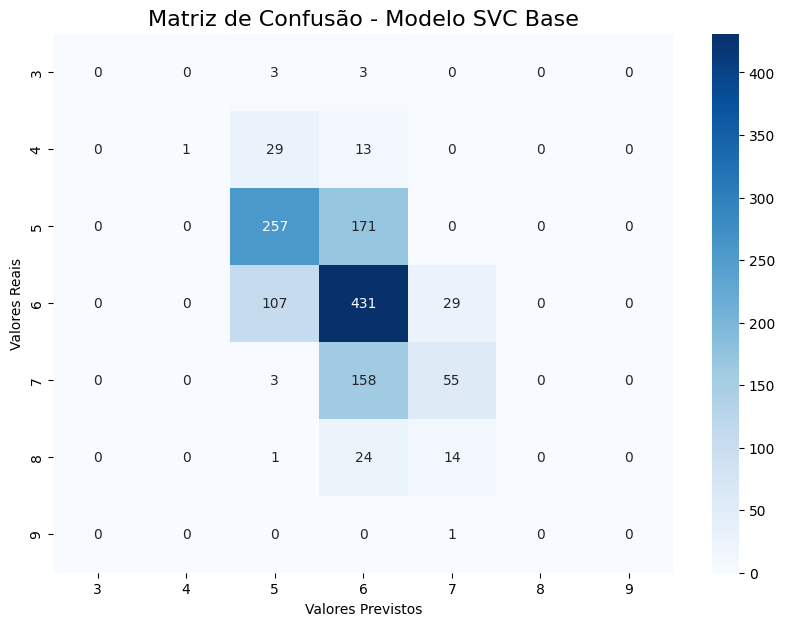

In [103]:
# Avaliação: Matriz de Confusão
print("Matriz de Confusão (SVC Base)")
print()
cm = confusion_matrix(y_test, y_pred_svc)

labels = sorted(y_test.unique())

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Modelo SVC Base', fontsize=16)
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.show()

## Gridsearch para SVC

In [104]:
# Parâmetros para o SVC com kernel 'rbf'
DicGradeHP = {'C': [0.01, 0.1, 1, 10, 100, 1000],
              'gamma': [0.01, 0.1, 1, 10, 100, 1000]
              }

In [106]:
grid_svc = GridSearchCV(
    estimator=clf_SVC,
    param_grid=DicGradeHP,
    cv=5,
    scoring='accuracy',
    verbose=0
)

grid_svc.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'gamma': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='accuracy')

In [111]:
print(f"Melhor pontuação encontrada: {grid_svc.best_score_:.4f}")
print("Melhores parâmetros encontrados:")
print(grid_svc.best_params_)

best_svc = grid_svc.best_estimator_

Melhor pontuação encontrada: 0.6298
Melhores parâmetros encontrados:
{'C': 10, 'gamma': 1}


## SVC otimizado

In [108]:
y_pred_best_svc = best_svc.predict(X_test_scaled)

# Relatório de Classificação (Otimizado)
print("Relatório de Classificação (SVC Otimizado)")
print()
print(classification_report(y_test, y_pred_best_svc, zero_division=0))

Relatório de Classificação (SVC Otimizado)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.46      0.14      0.21        43
           5       0.71      0.66      0.69       428
           6       0.62      0.73      0.67       567
           7       0.63      0.58      0.61       216
           8       0.62      0.38      0.48        39
           9       0.00      0.00      0.00         1

    accuracy                           0.65      1300
   macro avg       0.44      0.36      0.38      1300
weighted avg       0.65      0.65      0.64      1300



Matriz de Confusão (SVC Otimizado)



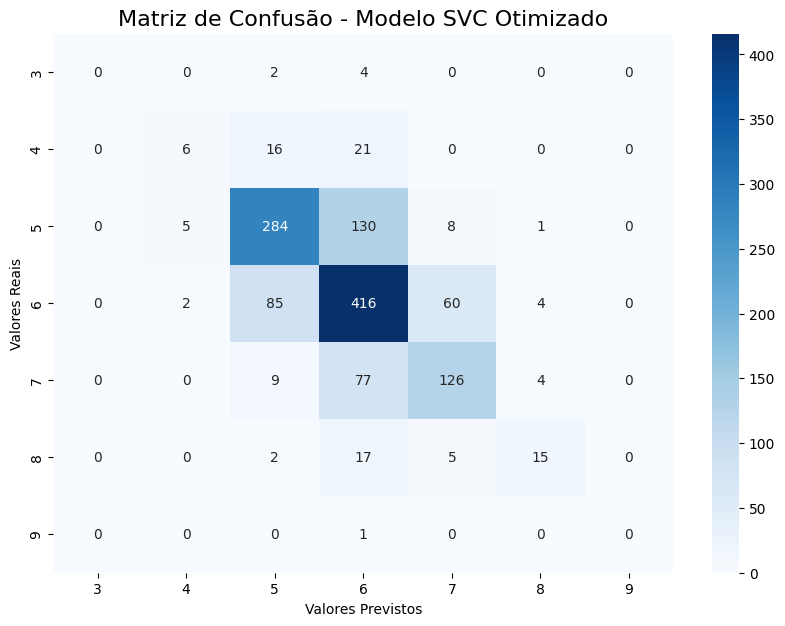

In [109]:
# Matriz de Confusão (Otimizado)
print("Matriz de Confusão (SVC Otimizado)")
print()
cm_best = confusion_matrix(y_test, y_pred_best_svc)
labels = sorted(y_test.unique())

plt.figure(figsize=(10, 7))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Modelo SVC Otimizado', fontsize=16)
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.show()

In [110]:
clf_SVC = SVC(C = grid_svc.best_params_['C'],
              gamma = grid_svc.best_params_['gamma'])
clf_SVC.fit(X_train_scaled,y_train)

# Previsões para os dados de teste
y_prev_teste = clf_SVC.predict(X_test_scaled)

# Cálculo da acurácia "final" (dados de teste)
acc_final = accuracy_score(y_true = y_test,y_pred = y_prev_teste)
print("Acurácia final (dados de teste) =",acc_final)

Acurácia final (dados de teste) = 0.6515384615384615
